In [1]:
import xarray as xr
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cmocean.cm as cm
import gsw
import arrow
from salishsea_tools import visualisations as vis
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
from matplotlib.ticker import FormatStrFormatter

In [2]:
bathy = nc.Dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc','r')
meshnc = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
depth = meshnc.variables['gdept_0'][:]
with xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc') as mesh:
    tmask = mesh.tmask
    mbathy = mesh.mbathy
    long = mesh.nav_lon
    latg = mesh.nav_lat
grid_dir = Path("/ocean/atall/MOAD/grid/")
grid_map = Path("grid_from_lat_lon_mask999.nc")
grid_lons_lats = xr.open_dataset(grid_dir / grid_map)
thalweg_SoG = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_ptsSoG = np.loadtxt(thalweg_SoG, delimiter=' ', dtype=int)
thalwegs =list([thalweg_ptsSoG])
depmin = list([450])

In [3]:
mesh

<xarray.Dataset> Size: 788MB
Dimensions:       (y: 898, x: 398, t: 1, z: 40)
Dimensions without coordinates: y, x, t, z
Data variables: (12/43)
    nav_lon       (y, x) float32 1MB ...
    nav_lat       (y, x) float32 1MB ...
    time_counter  (t) datetime64[ns] 8B ...
    tmask         (t, z, y, x) int8 14MB ...
    umask         (t, z, y, x) int8 14MB ...
    vmask         (t, z, y, x) int8 14MB ...
    ...            ...
    gdepv         (t, z, y, x) float32 57MB ...
    gdepw_0       (t, z, y, x) float32 57MB ...
    gdept_1d      (t, z) float64 320B ...
    gdepw_1d      (t, z) float64 320B ...
    e3t_1d        (t, z) float64 320B ...
    e3w_1d        (t, z) float64 320B ...
Attributes:
    file_name:    grid/mesh_mask202108.nc
    TimeStamp:    07/08/2021 17:25:49 -0700
    Conventions:  CF-1.6
    title:        SalishSeaCast NEMO bathymetry_202108 Bathymetry Mesh Mask
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       NEMO-3.6 SalishSeaCast configuration
    references:   https://github.com/SalishSeaCast/tools/blob/main/bathymetry...
    history:      [2021-08-07 17:25] ncks -4 -L4 -O mesh_mask.nc mesh_mask202...

### Bottom TimeSeries - Haro Strait (Boundary Pass) & Strait of Georgia (Central node)

In [4]:
# Obs cordonates: SoG Center: 49.039467°N, -123.425033°W, 300m ; SoG Est: 49.042586°N,  -123.316579°W, 166m
df_SoGO = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/SoG/SoG_Venus_Inst_Plattform/O2Sensor_20100101_20210101_clean_avg1day_SoGC_edit.csv')
df_SoGS = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/SoG/SoG_Venus_Inst_Plattform/CTD_Salinity_20100101_20210101_clean_avg1day_SoGC_edit.csv')
df_SoGT = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/SoG/SoG_Venus_Inst_Plattform/CTD_Temperature_20100101_20210101_clean_avg1day_SoGC_edit.csv')
# Obs cordonates: Boundary Pass: 48.765933°N, -123.038517°W, 228m 
df_HSBO = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/HaroStrait/O2Sensor_20100101_20210101_clean_avg1day_BP_edit.csv')
df_HSBS = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/HaroStrait/CTD_Salinity_20100101_20210101_clean_avg1day_BP_edit.csv')
df_HSBT = pd.read_csv('/ocean/atall/MOAD/Obs/ONC/HaroStrait/CTD_Temperature_20100101_20210101_clean_avg1day_BP_edit.csv')


In [5]:
# Convert objet dataframe to int
df_SoGO['oxy_sog'] = pd.to_numeric(df_SoGO['Oxygen Concentration Corrected (ml/l)'], errors='coerce')
df_SoGS['sal_sog'] = pd.to_numeric(df_SoGS['Practical Salinity (psu)'], errors='coerce')
df_SoGT['tem_sog'] = pd.to_numeric(df_SoGT['Temperature (C)'], errors='coerce')
df_SoGO['time'] = pd.to_datetime(df_SoGO['#"Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)"'])
df_SoGS['time'] = pd.to_datetime(df_SoGS['#"Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)"'])
df_SoGT['time'] = pd.to_datetime(df_SoGT['#"Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)"'])
df_HSBO['oxy_hsb'] = pd.to_numeric(df_HSBO['Oxygen Concentration Corrected (ml/l)'], errors='coerce')
df_HSBS['sal_hsb'] = pd.to_numeric(df_HSBS['Practical Salinity (psu)'], errors='coerce')
df_HSBT['tem_hsb'] = pd.to_numeric(df_HSBT['Temperature (C)'], errors='coerce')
df_HSBO['time'] = pd.to_datetime(df_HSBO['#"Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)"'])
df_HSBS['time'] = pd.to_datetime(df_HSBS['#"Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)"'])
df_HSBT['time'] = pd.to_datetime(df_HSBT['#"Time UTC (yyyy-mm-ddThh:mm:ss.fffZ)"'])
# from practical to ref salinity (g/kg)
df_SoGS['sal_sog'] = gsw.SR_from_SP(df_SoGS['sal_sog'])
df_HSBS['sal_hsb'] = gsw.SR_from_SP(df_HSBS['sal_hsb'])

In [6]:
jj_sog = grid_lons_lats.jj.sel(lats=49.039467, lons=-123.425033, method='nearest') # 305 m (Obs)
ii_sog = grid_lons_lats.ii.sel(lats=49.039467, lons=-123.425033, method='nearest')
jj_hsb = grid_lons_lats.jj.sel(lats=48.765933, lons=-123.038517, method='nearest') # 228 m (Obs)
ii_hsb = grid_lons_lats.ii.sel(lats=48.765933, lons=-123.038517, method='nearest')
print(ii_sog.item(),jj_sog.item())
print(ii_hsb.item(),jj_hsb.item())
print(df_SoGO.time[0],df_SoGS.time[0],df_SoGS.time[0])
print(df_HSBO.time[0],df_HSBS.time[0],df_HSBS.time[0])

266 423
289 343
2010-01-01 12:00:00+00:00 2010-01-01 12:00:00+00:00 2010-01-01 12:00:00+00:00
2012-10-15 12:00:00+00:00 2012-10-14 12:00:00+00:00 2012-10-14 12:00:00+00:00


In [7]:
for j in range(2):
    if j==0:
        jj, ii = (jj_hsb, ii_hsb)
    else:
        jj, ii = (jj_sog, ii_sog)
    print(np.array(mesh.e3t_0[0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)))

13.855081927741471
12.431097719657611


#### Figure 4

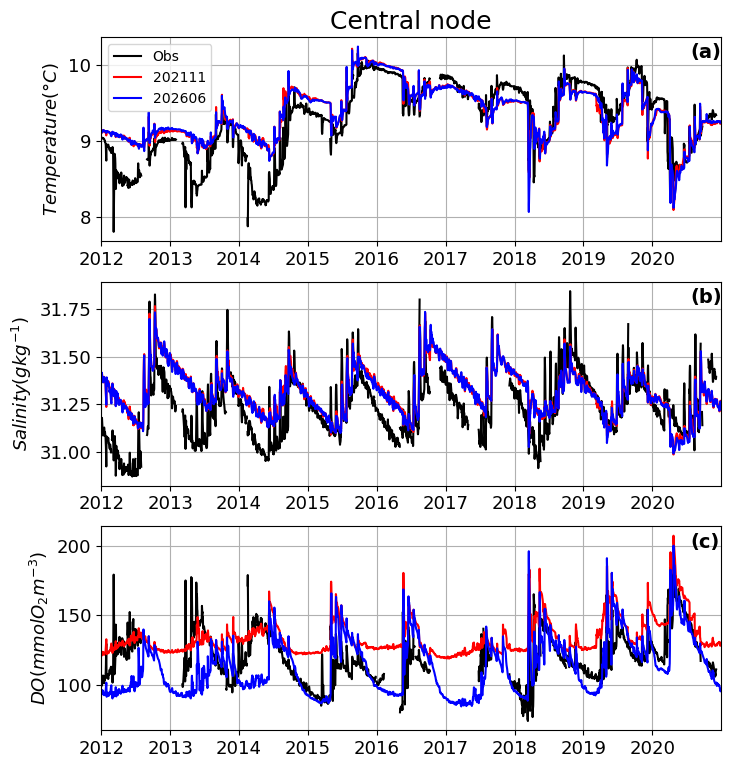

In [9]:
place = list(['SoG-Central node-300m'])
varname = ['$Temperature (°C)$','$Salinity (g kg^{-1})$','$DO (mmolO_2m^{-3})$']
line, col = (len(varname), len(place))
ti=2*365-31
te=ti+365*9+2
syear, smonth, sday = (2012, 1, 1)
eyear, emonth, eday = (2020, 12, 31)
#eyear, emonth, eday = (2012, 1, 3) # for test 
fig, ax = plt.subplots(3, 1, figsize=(8, 9))
ax[0].plot(df_SoGT.time[ti:te], df_SoGT.tem_sog[ti:te], 'k', label='Obs')
ax[1].plot(df_SoGS.time[ti:te], df_SoGS.sal_sog[ti:te], 'k', label='Obs')
ax[2].plot(df_SoGO.time[ti:te], df_SoGO.oxy_sog[ti:te]*44.661, 'k', label='Obs')

for alpha in range(2):
    if alpha == 0:
        dir = '/results2/SalishSea/nowcast-green.202111/'
        colors = 'red'
        labels = '202111'
    elif alpha == 1:
        dir = '/ocean/atall/MOAD/Model/202606/'
        colors = 'blue'
        labels = '202606'
    startdate = arrow.get(syear, smonth, sday)
    enddate = arrow.get(eyear, emonth, eday)    
    for j in range(col):
        jj, ii = (jj_sog, ii_sog)
        first,second = (True,True)
        for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
            year = day.year
            yr2 = day.strftime("%y")
            month = day.month
            Month = day.strftime("%b").lower()
            day = day.day
            # set up filename to follow NEMO conventions
            fchem = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc'
            fgrdT = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_grid_T.nc'
            with xr.open_dataset(fchem) as ds_chem:
                oxy0 = ds_chem['dissolved_oxygen'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
            with xr.open_dataset(fgrdT) as ds_grdT:
                sal0 = ds_grdT['vosaline'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                tem0 = ds_grdT['votemper'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
            
            if 'time' in ds_chem.variables.keys():
                continue
            if first:
                first = False
                oxy = oxy0
                sal = sal0
                tem = tem0
            else:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=FutureWarning)
                    oxy = xr.concat([oxy, oxy0], dim='time_counter')
                    sal = xr.concat([sal, sal0], dim='time_counter')
                    tem = xr.concat([tem, tem0], dim='time_counter')
            vars = list([tem,sal,oxy])
            
    yaxis=['yaxis','yaxis2','yaxis3']
    for i in range(len(vars)):
        ax[i].plot(vars[i].time_counter, vars[i], color=colors, label=labels)
        ax[i].set_ylabel(f'{varname[i]}',fontsize=13)
        ax[i].set_xlim(startdate,enddate)
        ax[i].tick_params(labelsize=13)
        ax[i].grid(True)
    if alpha == 0:
        tem_202111 = tem.copy()
        sal_202111 = sal.copy()
        oxy_202111 = oxy.copy()
    elif alpha == 1:
        tem_202606 = tem.copy()
        sal_202606 = sal.copy()
        oxy_202606 = oxy.copy()
letters = ['(a)','(b)','(c)']
k = 0
for c in range(3):
    ax[c].text(0.95,0.97,letters[k],transform=ax[c].transAxes,fontweight='bold',va='top',fontsize=14)
    k += 1
ax[0].set_title('Central node',fontsize=18)
ax[0].legend()
plt.show()
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/figure4_TSO2_longTS.png',dpi=300)

ds = xr.Dataset(
    data_vars={
        # observations
        "temperature_obs": (("time_obs",),df_SoGT.tem_sog[ti:te]),
        "salinity_obs": (("time_obs",),df_SoGS.sal_sog[ti:te]),
        "oxygen_obs": (("time_obs",),df_SoGO.oxy_sog[ti:te] * 44.661),  # convert from ml/l to mmol/m3
        # model 202111
        "temperature_202111": (("time_model",),tem_202111.values),
        "salinity_202111": (("time_model",),sal_202111.values),
        "oxygen_202111": (("time_model",),oxy_202111.values),
        # model 202606
        "temperature_202606": (("time_model",),tem_202606.values),
        "salinity_202606": (("time_model",),sal_202606.values),
        "oxygen_202606": (("time_model",),oxy_202606.values),},
    coords={"time_obs": df_SoGT.time[ti:te],"time_model": tem_202606.time_counter.values,},
    attrs={
        "title": "Processed data used to generate Figure 4",
        "location": "Strait of Georgia (Central Node, bottom cell ~300 m)",
        "model_versions": "202111 and 202606",
        "description": "Observed and simulated bottom temperature, salinity and dissolved oxygen time series."}
)

ds.to_netcdf("/ocean/atall/MOAD/Talletal_OxygenSoGpaper/data/Fig4_CentralNode_timeseries.nc")

#### Figure 5

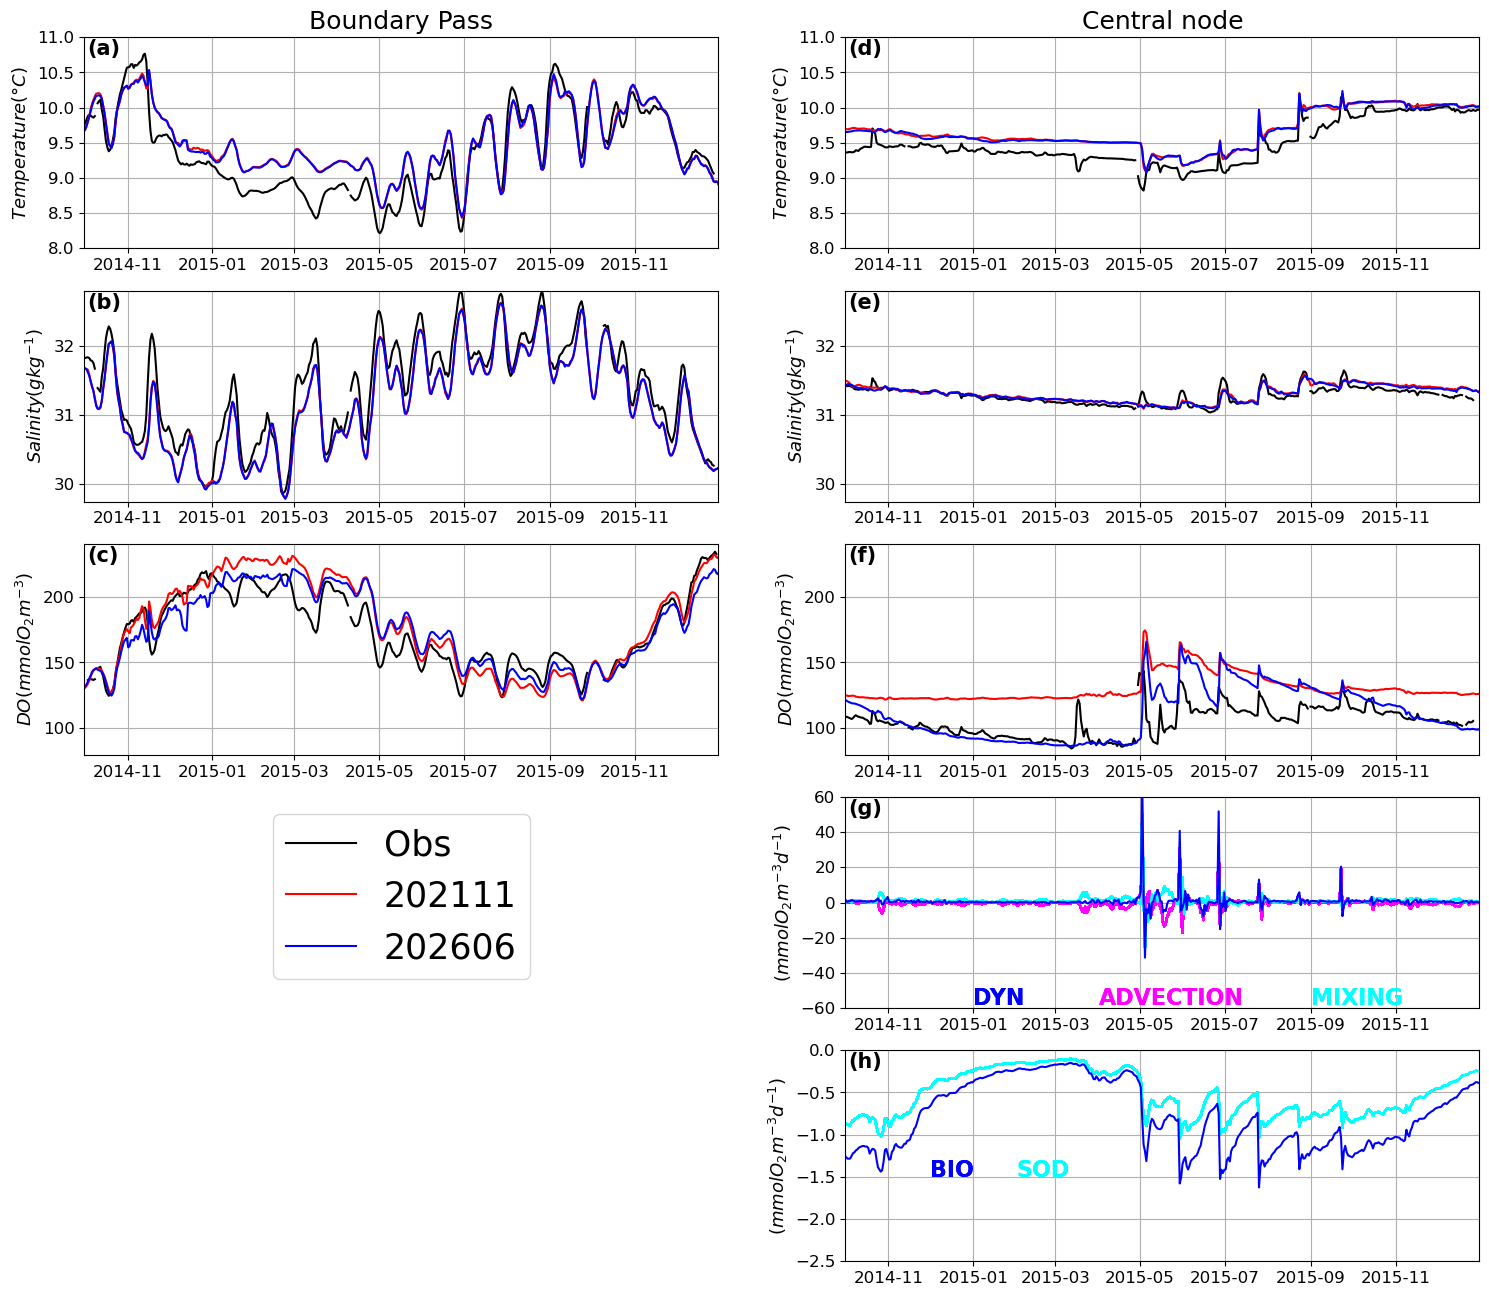

In [8]:
place = list(['Boundary Pass','Central node'])
varname = ['$Temperature (°C)$','$Salinity (g kg^{-1})$','$DO (mmolO_2m^{-3})$','$(mmolO_2m^{-3}d^{-1})$','$(mmolO_2m^{-3}d^{-1})$']
ymin,ymax = list([8,29.75,80,-60,-2.5]),list([11,32.8,240,60,0])
line, col = (len(varname), len(place))
ti0=79+365+275
te0=ti0+456
ti1=365*4+267
te1=ti1+456
conv = 86400
syear, smonth, sday = (2014, 10, 1)
eyear, emonth, eday = (2015, 12, 31)
#eyear, emonth, eday = (2014, 10, 3) # test

fig, ax = plt.subplots(5, 2, figsize=(18, 18))
# Boundary Pass
ax[0,0].plot(df_HSBT.time[ti0:te0], df_HSBT.tem_hsb[ti0:te0], 'k', label='Obs')
ax[1,0].plot(df_HSBS.time[ti0:te0], df_HSBS.sal_hsb[ti0:te0], 'k', label='Obs')
ax[2,0].plot(df_HSBO.time[ti0+1:te0], df_HSBO.oxy_hsb[ti0+1:te0]*44.661, 'k', label='Obs')
#Central node
ax[0,1].plot(df_SoGT.time[ti1:te1], df_SoGT.tem_sog[ti1:te1], 'k', label='Obs')
ax[1,1].plot(df_SoGS.time[ti1:te1], df_SoGS.sal_sog[ti1:te1], 'k', label='Obs')
ax[2,1].plot(df_SoGO.time[ti1:te1], df_SoGO.oxy_sog[ti1:te1]*44.661, 'k', label='Obs')

fig4_data = {}
for alpha in range(2):
    if alpha == 0:
        dir = '/results2/SalishSea/nowcast-green.202111/'
        colors = 'red'
        labels = '202111'
    elif alpha == 1:
        dir = '/ocean/atall/MOAD/Model/202606/'
        colors = 'blue'
        labels = '202606'
    startdate = arrow.get(syear, smonth, sday)
    enddate = arrow.get(eyear, emonth, eday)    
    for j in range(col):
        if j==0:
            jj, ii = (jj_hsb, ii_hsb)
        else:
            jj, ii = (jj_sog, ii_sog)
        first,second = (True,True)
        for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
            year = day.year
            yr2 = day.strftime("%y")
            month = day.month
            Month = day.strftime("%b").lower()
            day = day.day
            # set up filename to follow NEMO conventions
            fchem = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc'
            fgrdT = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_grid_T.nc'
            with xr.open_dataset(fchem) as ds_chem:
                oxy0 = ds_chem['dissolved_oxygen'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
            with xr.open_dataset(fgrdT) as ds_grdT:
                sal0 = ds_grdT['vosaline'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                tem0 = ds_grdT['votemper'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
            
            if 'time' in ds_chem.variables.keys():
                continue
            if first:
                first = False
                oxy = oxy0
                sal = sal0
                tem = tem0
            else:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=FutureWarning)
                    oxy = xr.concat([oxy, oxy0], dim='time_counter')
                    sal = xr.concat([sal, sal0], dim='time_counter')
                    tem = xr.concat([tem, tem0], dim='time_counter')
            if alpha==0: # no diag_T file for 202111 version
                vars = list([tem,sal,oxy])
            else:
                if j==1:
                    fdiag = f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_diag_T.nc'
                    with xr.open_dataset(fdiag) as ds_diag:
                        tnd0 = ds_diag['RATE_O2'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                        phs0 = ds_diag['PHS_O2'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                        bio0 = ds_diag['BIO_O2'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                        sms0 = ds_diag['SMS_O2'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                        ldf0 = ds_diag['LDF_O2'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                        zdf0 = ds_diag['ZDF_O2'][0, mbathy[0, jj, ii]-1, jj, ii].where(tmask[0, mbathy[0, jj, ii]-1, jj, ii] == 1)
                    if second:
                        second = False
                        tnd = tnd0
                        phs = phs0
                        bio = bio0
                        sms = sms0
                        zdf = zdf0
                        ldf = ldf0
                        #adv = adv0
                    else:
                        with warnings.catch_warnings():
                            warnings.filterwarnings("ignore", category=FutureWarning)
                            tnd = xr.concat([tnd, tnd0], dim='time_counter')
                            phs = xr.concat([phs, phs0], dim='time_counter')
                            bio = xr.concat([bio, bio0], dim='time_counter')
                            sms = xr.concat([sms, sms0], dim='time_counter')
                            zdf = xr.concat([zdf, zdf0], dim='time_counter')
                            ldf = xr.concat([ldf, ldf0], dim='time_counter')
                    vars = list([tem,sal,oxy,conv*phs,conv*bio])
                
                    ax[3,j].plot(phs.time_counter, (phs-ldf-zdf)*conv, color='magenta')
                    ax[3,j].plot(zdf.time_counter, (ldf+zdf)*conv, color='cyan')
                    ax[4,j].plot(sms.time_counter, (bio-sms)*conv, color='cyan')
                else:
                    vars = list([tem,sal,oxy])
        for i in range(len(vars)):
            ax[i,j].plot(vars[i].time_counter, vars[i], color=colors, label=labels)
            ax[i,j].set_ylabel(f'{varname[i]}',fontsize=13)
            ax[0,j].set_title(f'{place[j]}',fontsize=18)
            ax[i,j].set_ylim(ymin[i],ymax[i])
            ax[i,j].tick_params(labelsize=12)
            ax[i,j].set_xlim(startdate,enddate)
            ax[i,j].grid(True)
            if i==2 and j==0:
                #ax[i,j].legend(fontsize=12)
                ax[i,j].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=1, fontsize=25)
                plt.subplots_adjust(bottom=0.2) 
        if j==1:
            ax[3,j].text(arrow.get(2015, 1, 1),-58, r"DYN",fontsize=16,color='blue',weight='bold')
            ax[3,j].text(arrow.get(2015, 4, 1),-58, r"ADVECTION",fontsize=16,color='magenta',weight='bold')
            ax[3,j].text(arrow.get(2015, 9, 1),-58, r"MIXING",fontsize=16,color='cyan',weight='bold')
            ax[4,j].text(arrow.get(2014, 12, 1),-1.5, r"BIO",fontsize=16,color='blue',weight='bold')
            ax[4,j].text(arrow.get(2015, 2, 1),-1.5, r"SOD",fontsize=16,color='cyan',weight='bold')
    if alpha == 0 and j == 0:
        fig4_data["BP_tem_202111"] = tem.values
        fig4_data["BP_sal_202111"] = sal.values
        fig4_data["BP_oxy_202111"] = oxy.values

    if alpha == 1 and j == 0:
        fig4_data["BP_tem_202606"] = tem.values
        fig4_data["BP_sal_202606"] = sal.values
        fig4_data["BP_oxy_202606"] = oxy.values

    if alpha == 0 and j == 1:
        fig4_data["CN_tem_202111"] = tem.values
        fig4_data["CN_sal_202111"] = sal.values
        fig4_data["CN_oxy_202111"] = oxy.values

    if alpha == 1 and j == 1:
        fig4_data["CN_tem_202606"] = tem.values
        fig4_data["CN_sal_202606"] = sal.values
        fig4_data["CN_oxy_202606"] = oxy.values

        fig4_data["DYN"] = (phs*conv).values
        fig4_data["BIO"] = (bio*conv).values
        fig4_data["ADV"] = ((phs-ldf-zdf)*conv).values
        fig4_data["MIX"] = ((ldf+zdf)*conv).values
        fig4_data["SOD"] = ((bio-sms)*conv).values
        # save time only once
        fig4_data["time"] = tem.time_counter.values

letters = ['(a)','(d)','(b)','(e)','(c)','(f)','','(g)','','(h)']
k = 0
for r in range(5):
    for c in range(2):
        ax[r,c].text(0.005,0.99,letters[k],transform=ax[r,c].transAxes,fontweight='bold',va='top',fontsize=15)
        k += 1
ax[(3, 0)].axis('off')
ax[(4, 0)].axis('off')
ax[(3, 0)].axis('off')
ax[(4, 0)].axis('off')

fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/figure_TSO2budget_zoom2015_FIRST_BP-CN.png',dpi=300)

stations = ["Boundary Pass", "Central Node"]

ds = xr.Dataset(coords={"time": fig4_data["time"],"station": stations})

ds.to_netcdf("/ocean/atall/MOAD/Talletal_OxygenSoGpaper/data/Fig5_bottom_timeseries.nc")



#### Figure 6

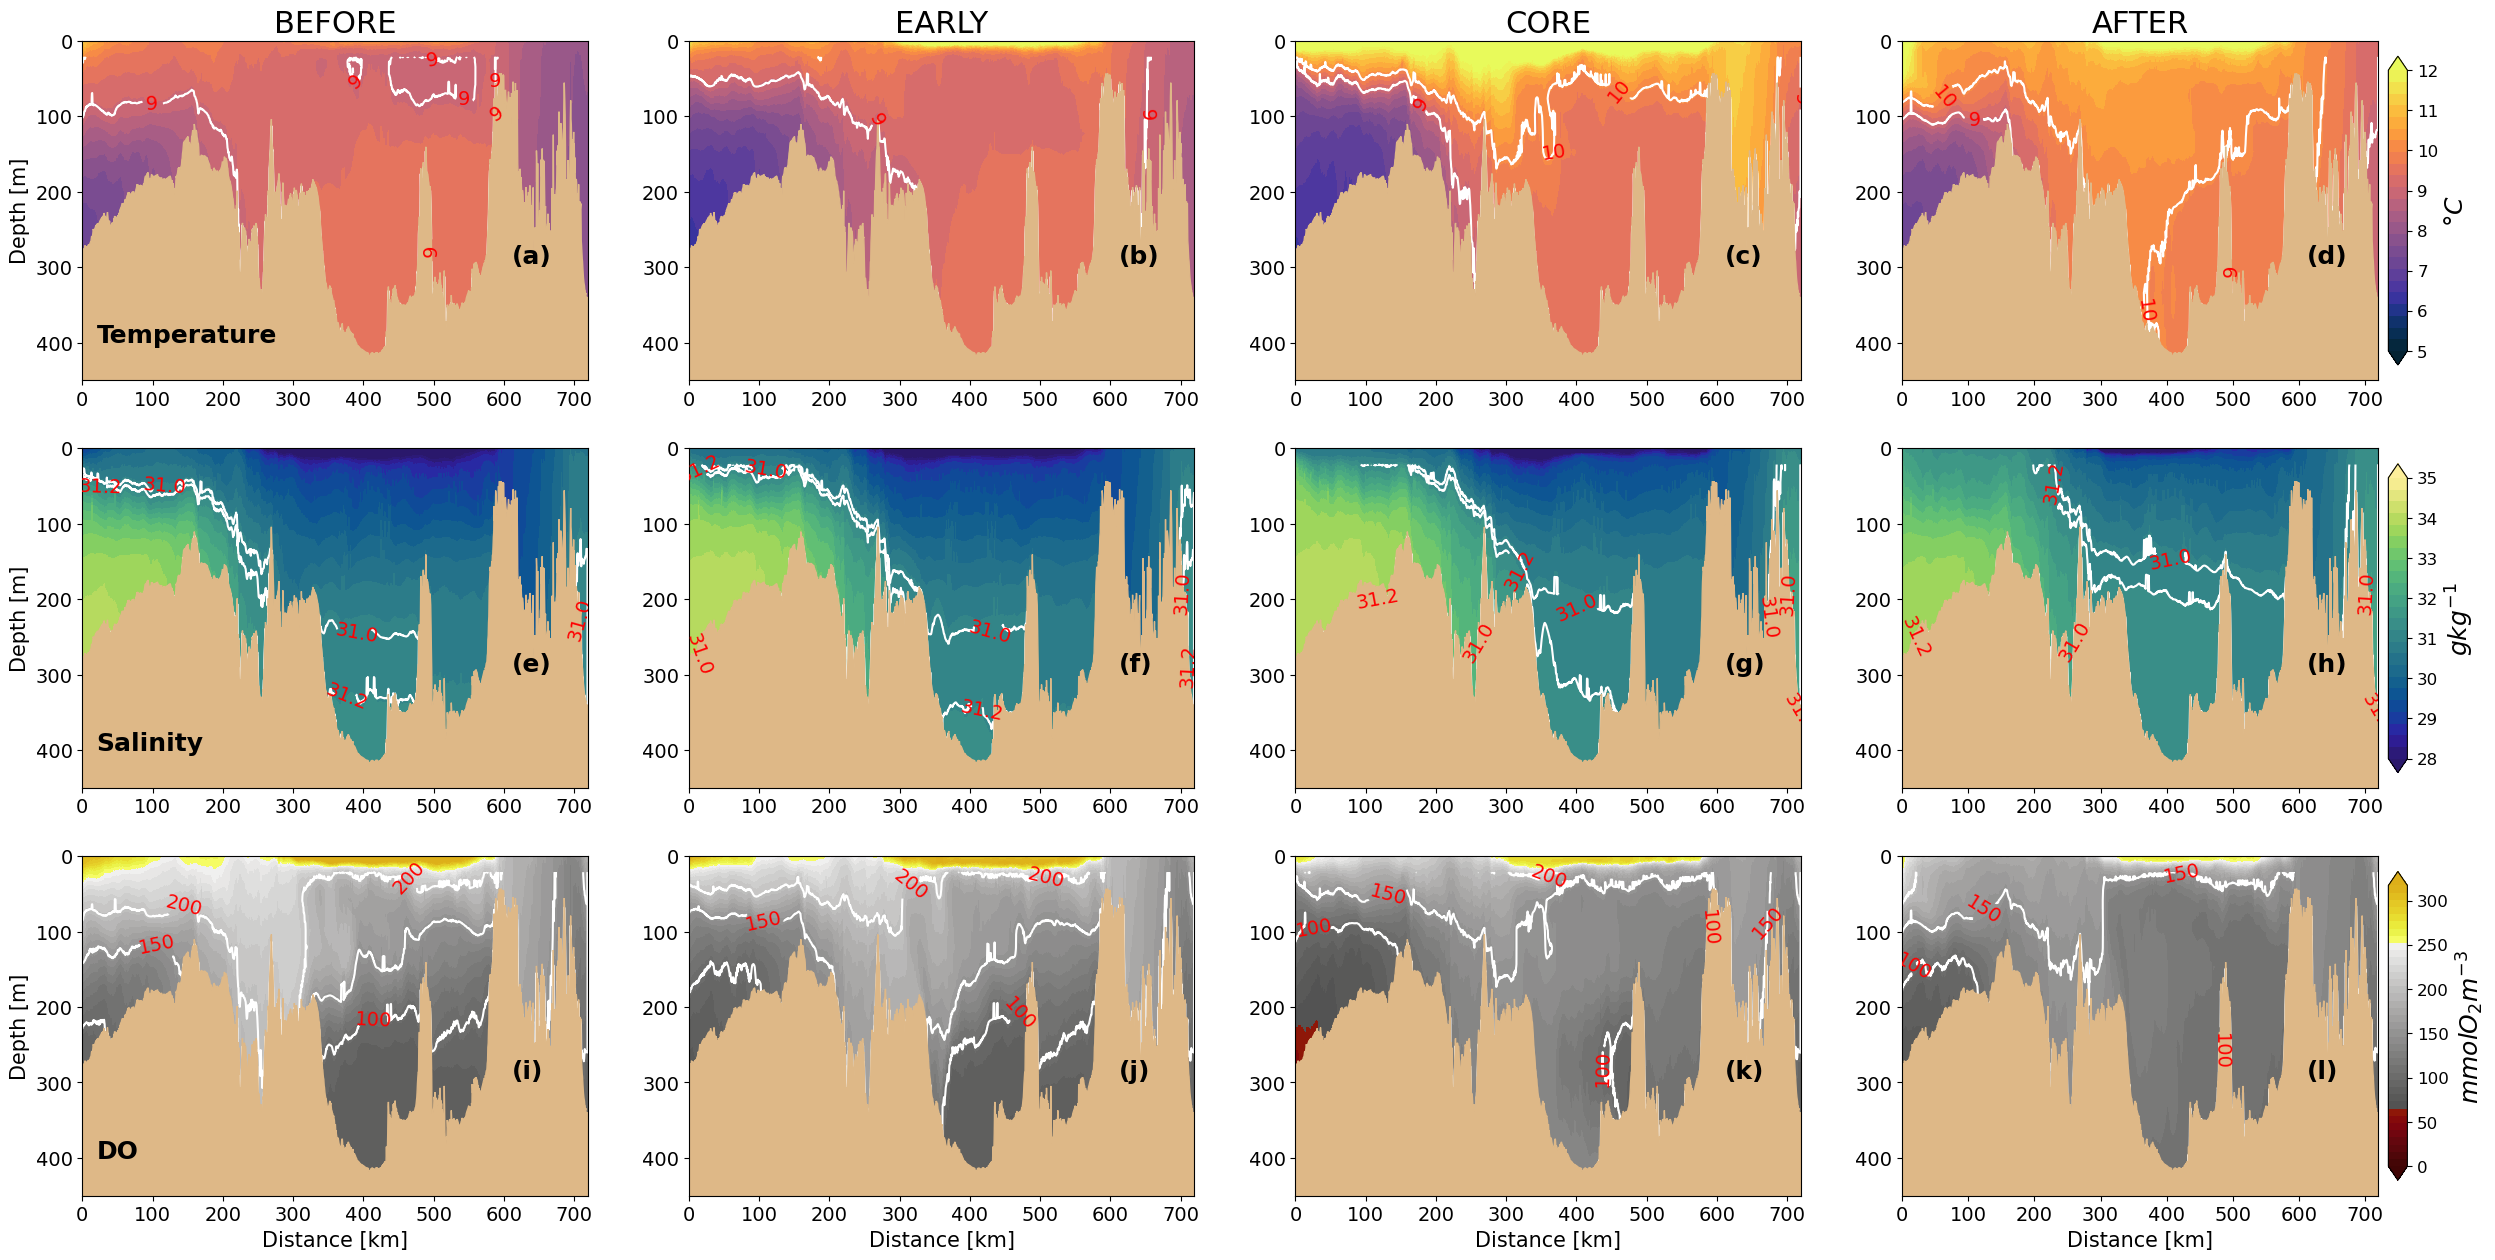

In [ ]:
k, line, col, conv = (0, 3, 4, 86400)
fig, ax = plt.subplots(line, col, figsize=(30, 15))
dir = '/ocean/atall/MOAD/Model/202606/'
period = list(['BEFORE','EARLY','CORE','AFTER'])
temp_save = []
sal_save = []
oxy_save = []
title = list(['Temperature','Salinity','DO'])
label = list(['$°C$','$g kg^{-1}$','$mmolO_2m^{-3}$'])

for j in range(col): #change period
    if j==0: # before the first deep water renew
        syear, smonth, sday = (2015, 4, 1)
        eyear, emonth, eday = (2015, 4, 15)
    elif j==1: # first deep water renew
        syear, smonth, sday = (2015, 5, 1)
        eyear, emonth, eday = (2015, 5, 15)
    elif j==2: # core of deep water renew
        syear, smonth, sday = (2015, 7, 20)
        eyear, emonth, eday = (2015, 8, 5)
    else: # after renewal
        syear, smonth, sday = (2015, 10, 15)
        eyear, emonth, eday = (2015, 10, 30)
    
    startdate = arrow.get(syear, smonth, sday)
    enddate = arrow.get(eyear, emonth, eday)
    first = True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        ds_chem = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc') 
        ds_grdT = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_grid_T.nc') 
        
        dep_thal, distance, oxy_thal = vis.load_thalweg(depth[0, ...], np.array(ds_chem.dissolved_oxygen).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        dep_thal, distance, sal_thal = vis.load_thalweg(depth[0, ...], np.array(ds_grdT.vosaline).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        dep_thal, distance, tem_thal = vis.load_thalweg(depth[0, ...], np.array(ds_grdT.votemper).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        if first:
            first = False
            oxyTS = oxy_thal
            salTS = sal_thal
            temTS = tem_thal
        else:
            oxyTS = np.vstack((oxyTS, oxy_thal))  
            salTS = np.vstack((salTS, sal_thal)) 
            temTS = np.vstack((temTS, tem_thal))
            
    oxy = oxyTS.reshape(len(oxyTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k])) 
    sal = salTS.reshape(len(salTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k]))  
    tem = temTS.reshape(len(temTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k]))  

    temp_mean = tem.mean(axis=0)
    sal_mean  = sal.mean(axis=0)
    oxy_mean  = oxy.mean(axis=0)

    temp_save.append(temp_mean)
    sal_save.append(sal_mean)
    oxy_save.append(oxy_mean)
    
    for i in range (line):
        if i==0:
            var = tem
            space = np.linspace(5, 12, 25)
            cont = [9, 10]
            ticks = [5, 6, 7, 8, 9, 10, 11, 12]
            cmap = cm.thermal
        elif i==1:
            var = sal
            space = np.linspace(28, 35, 25)
            cont = [31, 31.2]
            ticks = [28, 29, 30, 31, 32, 33, 34, 35]
            cmap = cm.haline
        elif i==2:
            cmap=cm.oxy
            var = oxy
            space = np.linspace(0, 317, 40)
            cont = [100, 150, 200]
            ticks = [0, 50, 100, 150, 200, 250, 300]
       
        var_plot = vis._fill_in_bathy(var.mean(axis=0), mesh, thalwegs[k])
        colours_var = ax[i,j].contourf(distance, dep_thal, var_plot, space, cmap=cmap, extend='both')
        var_contour = var_plot.copy()
        mask = dep_thal < 20
        var_contour = np.ma.masked_where(mask[:, np.newaxis].squeeze(), var_contour.squeeze())
        colourc_var = ax[i,j].contour(distance, dep_thal, var_contour, cont, zorder=1, colors='white', linewidths=1.5)
        ax[i,j].clabel(colourc_var, inline=True, colors='red', fontsize=14)
        vis._add_bathy_patch(distance, bathy['Bathymetry'][:], thalwegs[k], ax[i,j], color='burlywood')
        ax[i,j].invert_yaxis()
        ax[i,0].set_ylabel('Depth [m]',fontsize=15)
        ax[2,j].set_xlabel('Distance [km]',fontsize=15)
        ax[i,j].set_ylim([depmin[k], 0])
        ax[0,j].set_title(f'{period[j]}',fontsize=22)
        ax[i,j].tick_params(labelsize=14)
        if j==0:
            ax[i,j].text(20,400,f'{title[i]}',fontsize=18,weight='bold')
        elif j==3:
            divider = make_axes_locatable(ax[i,j])
            cax = divider.append_axes('right', size="4%", pad=0.1)
            cbar = fig.colorbar(colours_var, cax=cax)
            #cbar.ax.set_ylabel(f'{label[i]}',fontsize=18)
            cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
            cbar = fig.colorbar(colours_var,cax=cax,ticks=ticks)
            cbar.set_label(f'{label[i]}', fontsize=18)
            cbar.ax.tick_params(labelsize='large')
letters = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)']
k = 0
for r in range(3):
    for c in range(4):
        ax[r,c].text(0.85,0.4,letters[k],transform=ax[r,c].transAxes,fontweight='bold',va='top',fontsize=18)
        k += 1
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/figure_TSO2_BECA.png', dpi=300, bbox_inches='tight')


ds = xr.Dataset(
    data_vars={
        "temperature": (("period","depth","distance"),np.array(temp_save)),
        "salinity": (("period","depth","distance"),np.array(sal_save)),
        "dissolved_oxygen": (("period","depth","distance"),np.array(oxy_save)),
        "period": period,
        "depth": (("depth","distance"),dep_thal),
        "distance": (("depth","distance"),distance)
    },
    attrs={
        "title":"Processed data used to generate Figure 6",
        "description":"15-day mean temperature, salinity and dissolved oxygen along the Salish Sea thalweg.",
        "model":"SalishSeaCast 202606",
        "year":"2015"
    }
)
ds.to_netcdf("/ocean/atall/MOAD/Talletal_OxygenSoGpaper/data/Figure6_processed.nc")

#### Figure S3

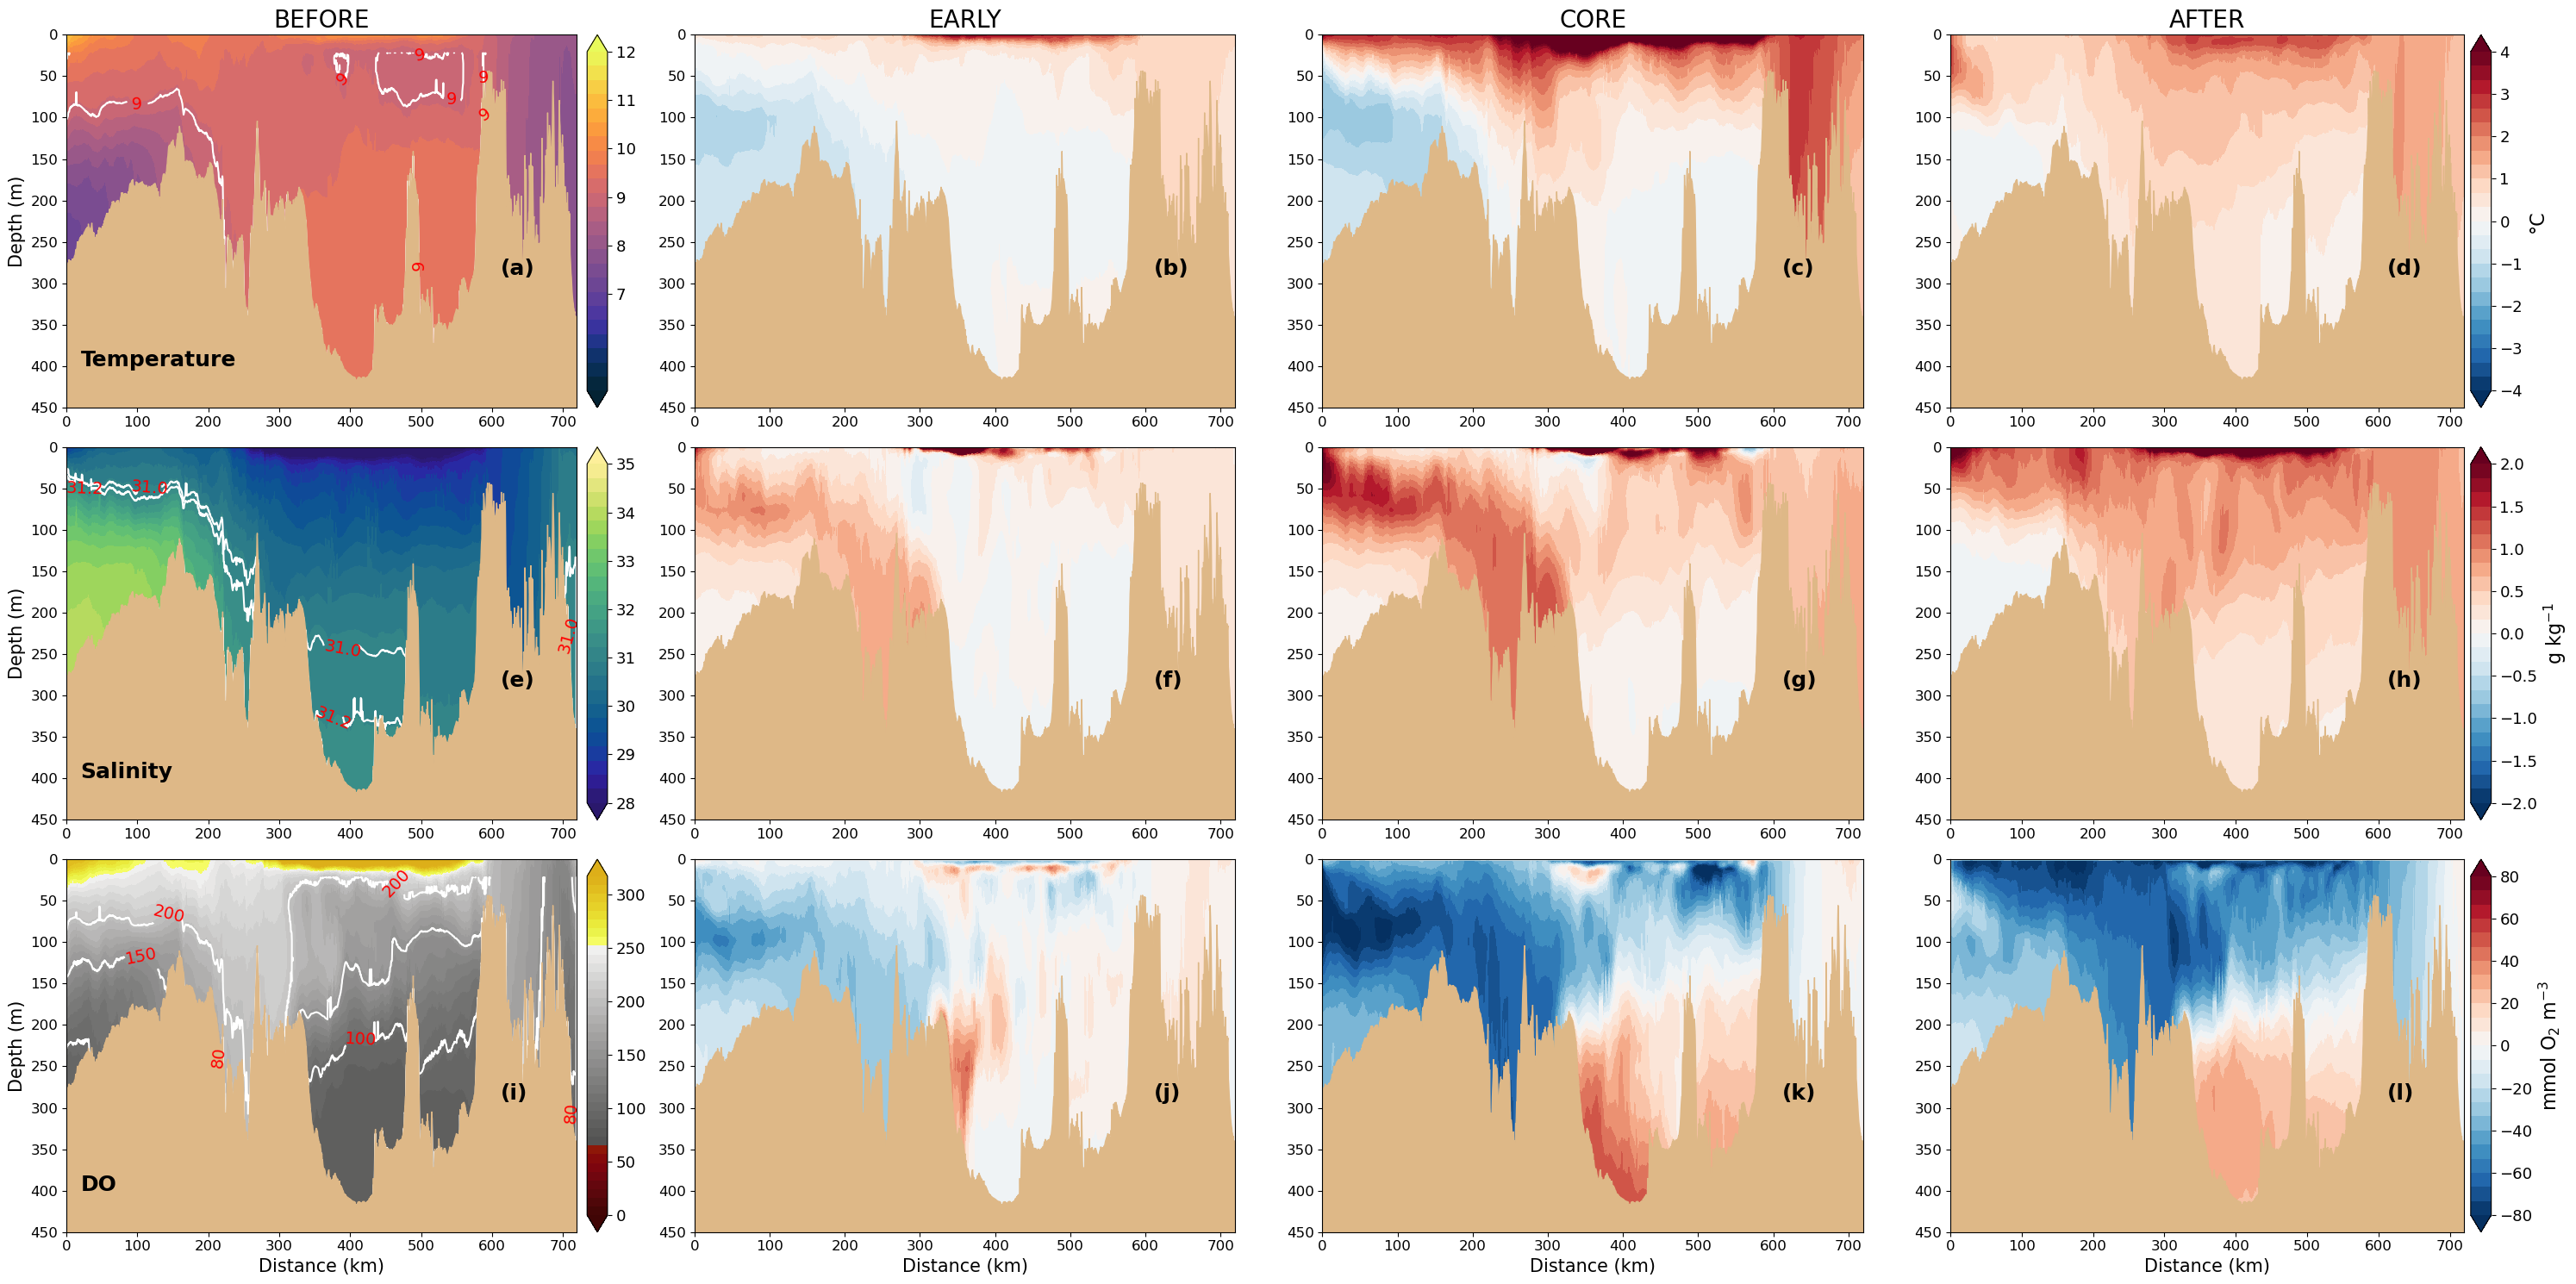

In [28]:
k = 0
line = 3
col = 4

fig, ax = plt.subplots(line, col, figsize=(30,15))

dir = '/ocean/atall/MOAD/Model/202606/'

period = ['BEFORE','EARLY','CORE','AFTER']
temp_save_anom = []
sal_save_anom = []
oxy_save_anom = []
title  = ['Temperature','Salinity','DO']
label  = ['°C','g kg$^{-1}$','mmol O$_2$ m$^{-3}$']

fields = {}

for j, per in enumerate(period):

    if per=="BEFORE":
        startdate = arrow.get(2015,4,1)
        enddate   = arrow.get(2015,4,15)
    elif per=="EARLY":
        startdate = arrow.get(2015,5,1)
        enddate   = arrow.get(2015,5,15)
    elif per=="CORE":
        startdate = arrow.get(2015,7,20)
        enddate   = arrow.get(2015,8,5)
    elif per=="AFTER":
        startdate = arrow.get(2015,10,15)
        enddate   = arrow.get(2015,10,30)

    first=True

    for day in arrow.Arrow.range("day",startdate,enddate):
        year=day.year
        yr2=day.strftime("%y")
        month=day.month
        Month=day.strftime("%b").lower()
        dd=day.day

        ds_chem = xr.open_dataset(f'{dir}{dd:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dd:02}_{year}{month:02}{dd:02}_chem_T.nc')

        ds_grdT = xr.open_dataset(f'{dir}{dd:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dd:02}_{year}{month:02}{dd:02}_grid_T.nc')

        dep_thal,distance,oxy = vis.load_thalweg(depth[0,...],np.array(ds_chem.dissolved_oxygen).mean(axis=0),bathy['nav_lon'][:],bathy['nav_lat'][:],thalwegs[k])

        dep_thal,distance,sal = vis.load_thalweg(depth[0,...],np.array(ds_grdT.vosaline).mean(axis=0),bathy['nav_lon'][:],bathy['nav_lat'][:], thalwegs[k])

        dep_thal,distance,temp = vis.load_thalweg(depth[0,...],np.array(ds_grdT.votemper).mean(axis=0),bathy['nav_lon'][:],bathy['nav_lat'][:],thalwegs[k])
        if first:
            first=False
            oxyTS=oxy
            salTS=sal
            temTS=temp
        else:
            oxyTS=np.vstack((oxyTS,oxy))
            salTS=np.vstack((salTS,sal))
            temTS=np.vstack((temTS,temp))

    nz=len(ds_chem.deptht)

    oxy=oxyTS.reshape(-1,nz,len(thalwegs[k])).mean(axis=0)
    sal=salTS.reshape(-1,nz,len(thalwegs[k])).mean(axis=0)
    tem=temTS.reshape(-1,nz,len(thalwegs[k])).mean(axis=0)

    fields[per]={"Temperature":tem,"Salinity":sal,"DO":oxy}

    temp_save_anom.append(tem)
    sal_save_anom.append(sal)
    oxy_save_anom.append(oxy)

for j,per in enumerate(period):
    for i,varname in enumerate(["Temperature","Salinity","DO"]):
        field=fields[per][varname]
        if per!="BEFORE":
            field=field-fields["BEFORE"][varname]
        field=vis._fill_in_bathy(field,mesh,thalwegs[k])
        if varname=="Temperature":
            if per=="BEFORE":
                levels=np.linspace(5,12,25)
                cmap=cm.thermal
                ticks=[5,6,7,8,9,10,11,12]
            else:
                levels=np.linspace(-4,4,25)
                cmap="RdBu_r"
                ticks=[-4,-3,-2,-1,0,1,2,3,4]
            contours=[9,10]

        elif varname=="Salinity":
            if per=="BEFORE":
                levels=np.linspace(28,35,25)
                cmap=cm.haline
                ticks=[28,29,30,31,32,33,33,34,35]
            else:
                levels=np.linspace(-2,2,25)
                cmap="RdBu_r"
                ticks=[-1,-0.5,0,0.5,1]
            contours=[31,31.2]

        elif varname=="DO":
            if per=="BEFORE":
                levels=np.linspace(0,317,40)
                cmap=cm.oxy
                ticks=[100,150,200]
            else:
                levels=np.linspace(-80,80,25)
                cmap="RdBu_r"
                ticks=[-80,-40,0,40,80]
            contours=[80,100,150,200]

        cf=ax[i,j].contourf(distance,dep_thal,field,levels,cmap=cmap,extend="both")

        contour_field=np.ma.masked_where(dep_thal[:,None].squeeze()<20,field.squeeze())

        colourc_var = ax[i,j].contour(distance,dep_thal,contour_field,contours,zorder=1,colors='white',linewidths=1.5)

        ax[i,j].clabel(colourc_var,inline=True,colors='red',fontsize=14)

        vis._add_bathy_patch(distance,bathy["Bathymetry"][:],thalwegs[k],ax[i,j],color="burlywood")

        ax[i,j].invert_yaxis()
        ax[i,j].set_ylim(depmin[k],0)

        ax[i,j].tick_params(labelsize='large')

        if j==0:
            ax[i,j].set_ylabel("Depth (m)",fontsize=15)
            ax[i,j].text(20,400,title[i],fontsize=18,weight="bold")

            divider = make_axes_locatable(ax[i,j])
            cax = divider.append_axes("right", size="4%", pad=0.12)
            cbar = fig.colorbar(cf, cax=cax)
            cbar.ax.tick_params(labelsize=13)
            if varname == "Temperature":
                cbar.set_ticks([7,8,9,10,11,12])
            elif varname == "Salinity":
                cbar.set_ticks([28,29,30,31,32,33,34,35])
            else:
                cbar.set_ticks([0,50,100,150,200,250,300])

        if i==2:
            ax[i,j].set_xlabel("Distance (km)",fontsize=15)
        if i==0:
            ax[i,j].set_title(per,fontsize=20)
        if j==3:
            divider=make_axes_locatable(ax[i,j])
            cax=divider.append_axes("right",size="4%",pad=0.08)
            cbar=fig.colorbar(cf,cax=cax)
            cbar.set_label(label[i],fontsize=16)
            cbar.ax.tick_params(labelsize=13)
letters = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)']
k = 0
for r in range(3):
    for c in range(4):
        ax[r,c].text(0.85,0.4,letters[k],transform=ax[r,c].transAxes,fontweight='bold',va='top',fontsize=18)
        k += 1
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/figure_TSO2_BECA_S3.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

ds = xr.Dataset(
    data_vars={
        "temperature": (("period","depth","distance"),np.array(temp_save_anom)),
        "salinity": (("period","depth","distance"),np.array(sal_save_anom)),
        "dissolved_oxygen": (("period","depth","distance"),np.array(oxy_save_anom)),
        "period": period,
        "depth": (("depth","distance"),dep_thal),
        "distance": (("depth","distance"),distance)
    },
    attrs={
        "title":"Processed data used to generate Figure S3",
        "description":"15-day mean temperature, salinity and dissolved oxygen along the Salish Sea thalweg.",
        "model":"SalishSeaCast 202410",
        "year":"2015"
    }
)
ds.to_netcdf("/ocean/atall/MOAD/Talletal_OxygenSoGpaper/data/FigS3_processed.nc")

#### Figure 7

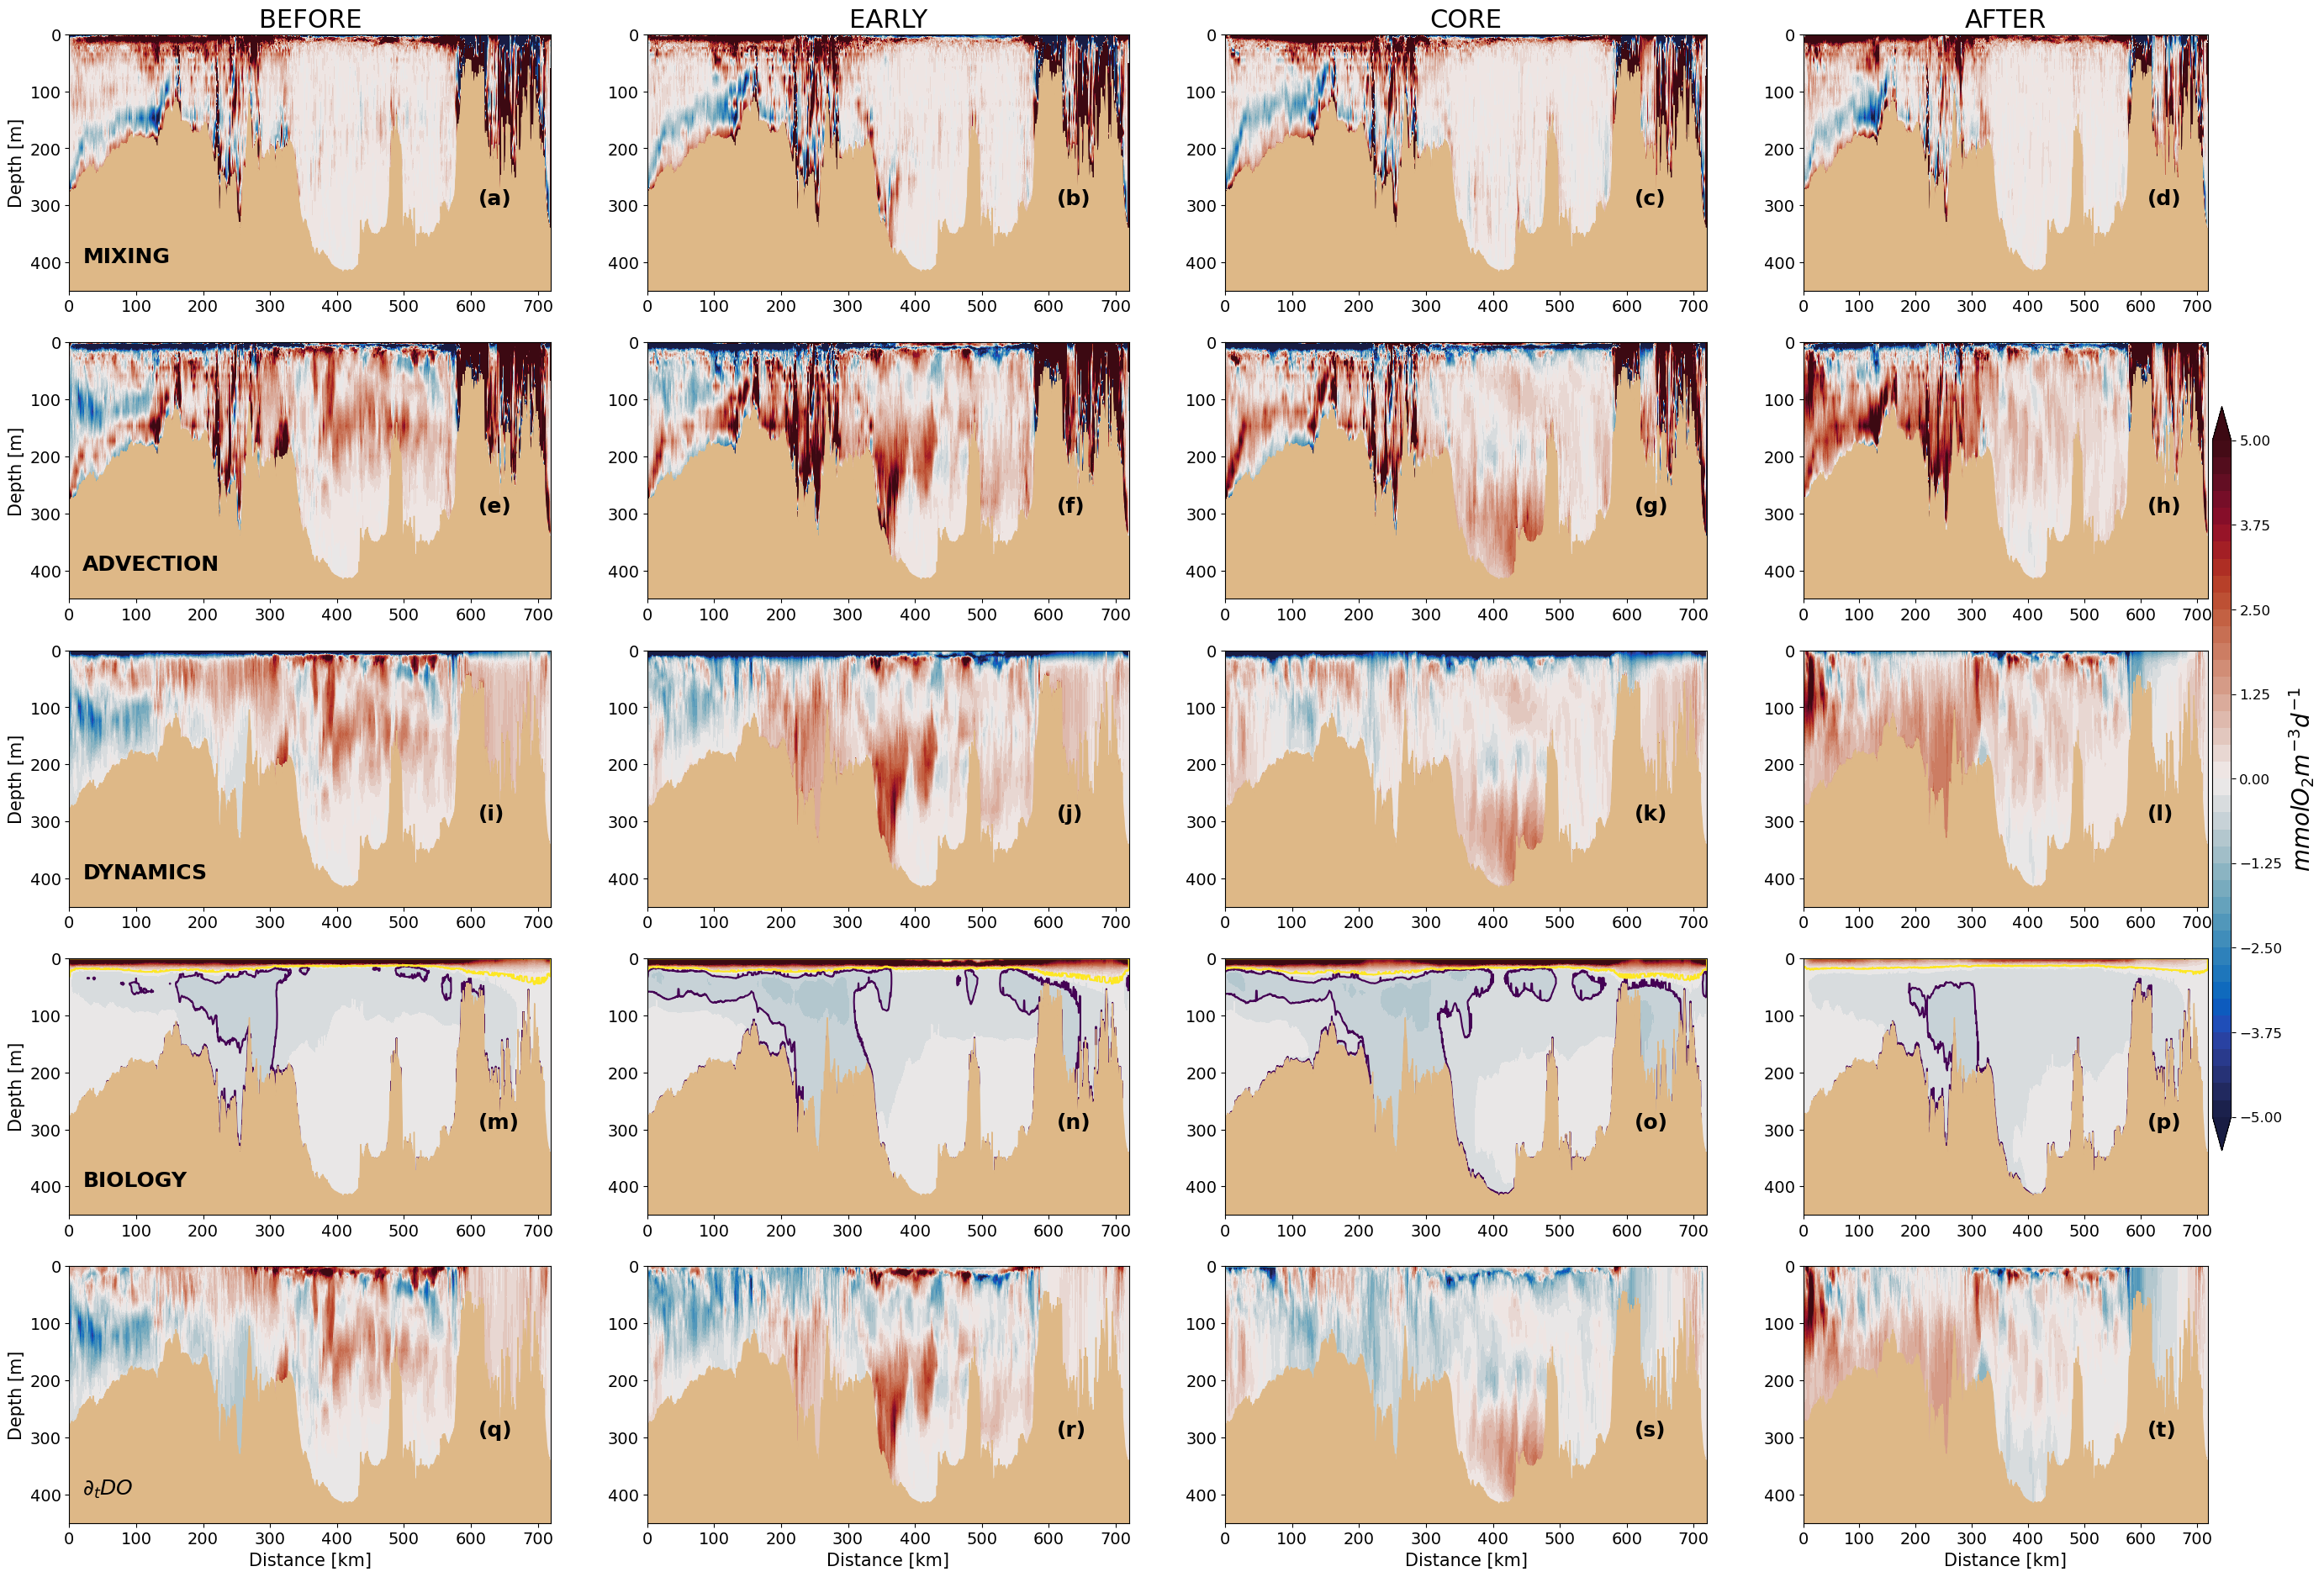

In [25]:
k, line, col, conv = (0, 5, 4, 86400)
fig, ax = plt.subplots(line, col, figsize=(34, 23))
dir = '/ocean/atall/MOAD/Model/202606/'
title = list(['MIXING','ADVECTION','DYNAMICS','BIOLOGY','$\\partial _t{DO}$'])
label = '$mmolO_2m^{-3}d^{-1}$'
mix_save = []
adv_save = []
dyn_save = []
bio_save = []
do2dt_save = []
for j in range(col): #change period
    if j==0: # before the first deep water renew
        syear, smonth, sday = (2015, 4, 1)
        eyear, emonth, eday = (2015, 4, 15)
    elif j==1: # first deep water renew
        syear, smonth, sday = (2015, 5, 1)
        eyear, emonth, eday = (2015, 5, 15)
    elif j==2: # core of deep water renew
        syear, smonth, sday = (2015, 7, 20)
        eyear, emonth, eday = (2015, 8, 5)
    else: # after renewal
        syear, smonth, sday = (2015, 10, 15)
        eyear, emonth, eday = (2015, 10, 30)
    
    startdate = arrow.get(syear, smonth, sday)
    enddate = arrow.get(eyear, emonth, eday)
    first = True
    for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
        year = day.year
        yr2 = day.strftime("%y")
        month = day.month
        Month = day.strftime("%b").lower()
        day = day.day
        # set up filename to follow NEMO conventions
        ds_diag = xr.open_dataset(f'{dir}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_diag_T.nc') 
       
        dep_thal, distance, mix_thal = vis.load_thalweg(depth[0, ...], conv*np.array(ds_diag.ZDF_O2+ds_diag.LDF_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        dep_thal, distance, phs_thal = vis.load_thalweg(depth[0, ...], conv*np.array(ds_diag.PHS_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        dep_thal, distance, bio_thal = vis.load_thalweg(depth[0, ...], conv*np.array(ds_diag.BIO_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        #dep_thal, distance, adv_thal = vis.load_thalweg(depth[0, ...], conv*np.array(ds_diag.TAD_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        dep_thal, distance, rate_thal = vis.load_thalweg(depth[0, ...], conv*np.array(ds_diag.RATE_O2).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalwegs[k])
        if first:
            first = False
            mixTS = mix_thal
            bioTS = bio_thal
            phsTS = phs_thal
            rateTS = rate_thal
            #advTS = adv_thal
        else:
            rateTS = np.vstack((rateTS, rate_thal)) 
            phsTS = np.vstack((phsTS, phs_thal))
            mixTS = np.vstack((mixTS, mix_thal))
            bioTS = np.vstack((bioTS, bio_thal)) 
    rate = rateTS.reshape(len(rateTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k]))  
    mix = mixTS.reshape(len(mixTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k])) 
    bio = bioTS.reshape(len(bioTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k]))  
    phs = phsTS.reshape(len(phsTS)//len(ds_chem.dissolved_oxygen['deptht']),len(ds_chem.dissolved_oxygen['deptht']),len(thalwegs[k]))  

    do2dt_mean = rate.mean(axis=0)
    bio_mean  = bio.mean(axis=0)
    dyn_mean  = phs.mean(axis=0)
    mix_mean  = mix.mean(axis=0)
    adv_mean  = dyn_mean-mix_mean
        
    do2dt_save.append(do2dt_mean)
    bio_save.append(bio_mean)
    dyn_save.append(dyn_mean) 
    mix_save.append(mix_mean)
    adv_save.append(adv_mean) 
    
    for i in range (line):
        cmap = cm.balance
        if i==0:
            var = mix
            cont = [1000000]
            space = np.linspace(-5, 5, 41)
        elif i==1:
            var = phs-mix
            #var = rate-bio-mix
        elif i==2:
            var = phs
            cont = [1000000]
        elif i==3:
            var = bio
            cont = [-0.5, 0]
        elif i==4:
            var = rate
            cont = [1000000]

        var_plot = vis._fill_in_bathy(var.mean(axis=0), mesh, thalwegs[k])
        colours_var = ax[i,j].contourf(distance, dep_thal, var_plot, space, cmap=cmap, extend='both')
        colourc_var = ax[i,j].contour(distance, dep_thal, var_plot, cont, zorder=1,linewidths=1.5)
        #ax[i,j].clabel(colourc_var, inline=True)
        vis._add_bathy_patch(distance, bathy['Bathymetry'][:], thalwegs[k], ax[i,j], color='burlywood')
        ax[i,j].invert_yaxis()
        ax[i,0].set_ylabel('Depth [m]',fontsize=15)
        ax[4,j].set_xlabel('Distance [km]',fontsize=15)
        ax[i,j].set_ylim([depmin[k], 0])
        ax[0,j].set_title(f'{period[j]}',fontsize=22)
        ax[i,j].tick_params(labelsize=14)
        if j==0:
            ax[i,j].text(20,400,f'{title[i]}',fontsize=18,weight='bold')
cbar = fig.colorbar(colours_var, ax=ax[:,3], location='right', pad=0.01, shrink=0.5, aspect=40)
cbar.ax.set_ylabel(f'{label}',fontsize=20)
cbar.ax.tick_params(labelsize='large')
letters = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)','(q)','(r)','(s)','(t)']
k = 0
for r in range(5):
    for c in range(4):
        ax[r,c].text(0.85,0.4,letters[k],transform=ax[r,c].transAxes,fontweight='bold',va='top',fontsize=18)
        k += 1
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/figure_TSO2budget_BECA.png', dpi=300, bbox_inches='tight')


ds = xr.Dataset(
    data_vars={
        "do2dt": (("period","depth","distance"),np.array(do2dt_save)),
        "BIO": (("period","depth","distance"),np.array(bio_save)),
        "DYN": (("period","depth","distance"),np.array(dyn_save)),
        "advection": (("period","depth","distance"),np.array(adv_save)),
        "mixing": (("period","depth","distance"),np.array(mix_save)),
        "period": period,
        "depth": (("depth","distance"),dep_thal),
        "distance": (("depth","distance"),distance)
    },
    attrs={
        "title":"Processed data used to generate Figure 7",
        "description":"15-day mean total DO change, BIO, DYN, Advection and Mixing along the Salish Sea thalweg.",
        "model":"SalishSeaCast 202410",
        "year":"2015"
    }
)
ds.to_netcdf("/ocean/atall/MOAD/Talletal_OxygenSoGpaper/data/Fig7_processed.nc")